In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

<h1 style="text-align: center; color: green;">Temas selectos de Riesgo de Financiero</h1>

### Practica 6 Riesgo de común y pérdida esperada

<!-- ![image.png](attachment:image.png) -->

<div style="text-align:center">
    <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRBzBoVxk4rqdWzm8JYC4_fxC6fa04CQWGGgQ&s" width="400">
</div>

#### Coeficiente de Gini: 

El Coeficiente de Gini se basa en la Curva de Lorenz, que es una
representación gráfica de una función de distribución acumulada. Es una medida estadística que cuantifica la desigualdad de ingresos o riqueza dentro de una población, variando de 0 (igualdad total) a 1 (desigualdad máxima). 

> cuanto más alta es la cifra, mayor es la concentración de ingresos en pocas manos.


#### Indice de Concentración de GINI.

$$ GINI = 1 - \sum_{i=1}^n (Y_i - Y_{i-1}) (X_i + X_{i-1})$$

Donde:

$X_i$: es el acumulado de empresas a partir de la más grande.

$Y_i$: es el porcentaje acumulado del monto de crédito.


- Un Gini cercano a 0 indica baja concentración. (El monto de crédito está relativamente bien distribuido entre los acreditados.
)

- Un Gini cercano a 1 indica alta concentración. (Una pequeña proporción de empresas concentra gran parte del monto de crédito.)



Valores altos del coeficiente de Gini indican que el crédito se encuentra altamente concentrado en pocos acreditados, incrementando el riesgo de concentración. Valores bajos reflejan una distribución más homogénea del portafolio y un menor riesgo común.

In [2]:
cartera = pd.read_csv('cartera.csv')
cartera

,Empresa,Monto de crédito,Calificación,Zona geografica,Sector Económico,Grupo Económico
0,X22,9.316336e+06,AAA,Noreste,Agricultura,X22
1,X41,7.658337e+06,BBB,Sureste,Minería,X41
2,X92,1.644680e+06,AAA,Noreste,Agricultura,X92
3,X62,4.960432e+06,AAA,Noreste,Agricultura,X62
4,X46,7.041822e+06,BBB,Sureste,Minería,X46
...,...,...,...,...,...,...
95,X77,3.355548e+06,AAA,Noreste,Agricultura,X77
96,X58,5.279938e+06,BB,Suroeste,Manufactura,X58
97,X9,6.500000e+07,A,Centro,Hoteleria,X9
98,X32,8.323439e+06,AAA,Noreste,Agricultura,X32


In [3]:
cartera_agrupado = cartera.sort_values('Monto de crédito', ascending=False).reset_index(drop=True)
cartera_agrupado

,Empresa,Monto de crédito,Calificación,Zona geografica,Sector Económico,Grupo Económico
0,X1,7.500000e+07,A,Centro,Hoteleria,X1
1,X2,7.200000e+07,AAA,Noreste,Agricultura,X2
2,X3,7.100000e+07,BB,Suroeste,Manufactura,X3
3,X4,7.050000e+07,AA,Noroeste,Alimentos,X4
4,X5,7.000000e+07,BB,Suroeste,Manufactura,X5
...,...,...,...,...,...,...
95,X96,9.865776e+05,BB,Suroeste,Manufactura,Grupo 1
96,X97,4.975602e+05,AA,Noroeste,Alimentos,X97
97,X98,3.838741e+05,AA,Noroeste,Alimentos,X98
98,X99,2.676546e+05,AA,Noroeste,Alimentos,X99


In [4]:
cartera_agrupado
cartera_agrupado

,Empresa,Monto de crédito,Calificación,Zona geografica,Sector Económico,Grupo Económico
0,X1,7.500000e+07,A,Centro,Hoteleria,X1
1,X2,7.200000e+07,AAA,Noreste,Agricultura,X2
2,X3,7.100000e+07,BB,Suroeste,Manufactura,X3
3,X4,7.050000e+07,AA,Noroeste,Alimentos,X4
4,X5,7.000000e+07,BB,Suroeste,Manufactura,X5
...,...,...,...,...,...,...
95,X96,9.865776e+05,BB,Suroeste,Manufactura,Grupo 1
96,X97,4.975602e+05,AA,Noroeste,Alimentos,X97
97,X98,3.838741e+05,AA,Noroeste,Alimentos,X98
98,X99,2.676546e+05,AA,Noroeste,Alimentos,X99


In [5]:
total_monto = cartera_agrupado['Monto de crédito'].sum()
total_monto

np.float64(1195844610.5688)

In [6]:
cartera_agrupado.index + 1

RangeIndex(start=1, stop=101, step=1)

In [7]:
cartera_agrupado['poblacion_acum'] = range(1, len(cartera_agrupado)+1)
cartera_agrupado

,Empresa,Monto de crédito,Calificación,Zona geografica,Sector Económico,Grupo Económico,poblacion_acum
0,X1,7.500000e+07,A,Centro,Hoteleria,X1,1
1,X2,7.200000e+07,AAA,Noreste,Agricultura,X2,2
2,X3,7.100000e+07,BB,Suroeste,Manufactura,X3,3
3,X4,7.050000e+07,AA,Noroeste,Alimentos,X4,4
4,X5,7.000000e+07,BB,Suroeste,Manufactura,X5,5
...,...,...,...,...,...,...,...
95,X96,9.865776e+05,BB,Suroeste,Manufactura,Grupo 1,96
96,X97,4.975602e+05,AA,Noroeste,Alimentos,X97,97
97,X98,3.838741e+05,AA,Noroeste,Alimentos,X98,98
98,X99,2.676546e+05,AA,Noroeste,Alimentos,X99,99


In [8]:
proporcion_monto_acumulado = cartera_agrupado['Monto de crédito'].cumsum() / total_monto

cartera_agrupado["monto_acum"] = proporcion_monto_acumulado
cartera_agrupado

,Empresa,Monto de crédito,Calificación,Zona geografica,Sector Económico,Grupo Económico,poblacion_acum,monto_acum
0,X1,7.500000e+07,A,Centro,Hoteleria,X1,1,0.062717
1,X2,7.200000e+07,AAA,Noreste,Agricultura,X2,2,0.122926
2,X3,7.100000e+07,BB,Suroeste,Manufactura,X3,3,0.182298
3,X4,7.050000e+07,AA,Noroeste,Alimentos,X4,4,0.241252
4,X5,7.000000e+07,BB,Suroeste,Manufactura,X5,5,0.299788
...,...,...,...,...,...,...,...,...
95,X96,9.865776e+05,BB,Suroeste,Manufactura,Grupo 1,96,0.998887
96,X97,4.975602e+05,AA,Noroeste,Alimentos,X97,97,0.999303
97,X98,3.838741e+05,AA,Noroeste,Alimentos,X98,98,0.999624
98,X99,2.676546e+05,AA,Noroeste,Alimentos,X99,99,0.999848


In [9]:
proporcion_monto_acumulado.shift(1)

0          NaN
1     0.062717
2     0.122926
3     0.182298
4     0.241252
        ...   
95    0.998062
96    0.998887
97    0.999303
98    0.999624
99    0.999848
Name: Monto de crédito, Length: 100, dtype: float64

In [10]:
yi_y_i_1 = proporcion_monto_acumulado - proporcion_monto_acumulado.shift(1).fillna(0)

cartera_agrupado["yi_y_i_1"] = yi_y_i_1
cartera_agrupado

,Empresa,Monto de crédito,Calificación,Zona geografica,Sector Económico,Grupo Económico,poblacion_acum,monto_acum,yi_y_i_1
0,X1,7.500000e+07,A,Centro,Hoteleria,X1,1,0.062717,0.062717
1,X2,7.200000e+07,AAA,Noreste,Agricultura,X2,2,0.122926,0.060208
2,X3,7.100000e+07,BB,Suroeste,Manufactura,X3,3,0.182298,0.059372
3,X4,7.050000e+07,AA,Noroeste,Alimentos,X4,4,0.241252,0.058954
4,X5,7.000000e+07,BB,Suroeste,Manufactura,X5,5,0.299788,0.058536
...,...,...,...,...,...,...,...,...,...
95,X96,9.865776e+05,BB,Suroeste,Manufactura,Grupo 1,96,0.998887,0.000825
96,X97,4.975602e+05,AA,Noroeste,Alimentos,X97,97,0.999303,0.000416
97,X98,3.838741e+05,AA,Noroeste,Alimentos,X98,98,0.999624,0.000321
98,X99,2.676546e+05,AA,Noroeste,Alimentos,X99,99,0.999848,0.000224


In [11]:
Xi_X_i_1 = (cartera_agrupado['poblacion_acum'] + cartera_agrupado['poblacion_acum'].shift(1).fillna(0)) / len(cartera_agrupado)

cartera_agrupado["Xi_X_i_1"] = Xi_X_i_1
cartera_agrupado

,Empresa,Monto de crédito,Calificación,Zona geografica,Sector Económico,Grupo Económico,poblacion_acum,monto_acum,yi_y_i_1,Xi_X_i_1
0,X1,7.500000e+07,A,Centro,Hoteleria,X1,1,0.062717,0.062717,0.01
1,X2,7.200000e+07,AAA,Noreste,Agricultura,X2,2,0.122926,0.060208,0.03
2,X3,7.100000e+07,BB,Suroeste,Manufactura,X3,3,0.182298,0.059372,0.05
3,X4,7.050000e+07,AA,Noroeste,Alimentos,X4,4,0.241252,0.058954,0.07
4,X5,7.000000e+07,BB,Suroeste,Manufactura,X5,5,0.299788,0.058536,0.09
...,...,...,...,...,...,...,...,...,...,...
95,X96,9.865776e+05,BB,Suroeste,Manufactura,Grupo 1,96,0.998887,0.000825,1.91
96,X97,4.975602e+05,AA,Noroeste,Alimentos,X97,97,0.999303,0.000416,1.93
97,X98,3.838741e+05,AA,Noroeste,Alimentos,X98,98,0.999624,0.000321,1.95
98,X99,2.676546e+05,AA,Noroeste,Alimentos,X99,99,0.999848,0.000224,1.97


In [12]:
cartera_agrupado.loc[0, "yi_y_i_1"] = proporcion_monto_acumulado.iloc[0]
cartera_agrupado.loc[0, "Xi_X_i_1"] = 1 / len(cartera_agrupado)

In [13]:
cartera_agrupado

,Empresa,Monto de crédito,Calificación,Zona geografica,Sector Económico,Grupo Económico,poblacion_acum,monto_acum,yi_y_i_1,Xi_X_i_1
0,X1,7.500000e+07,A,Centro,Hoteleria,X1,1,0.062717,0.062717,0.01
1,X2,7.200000e+07,AAA,Noreste,Agricultura,X2,2,0.122926,0.060208,0.03
2,X3,7.100000e+07,BB,Suroeste,Manufactura,X3,3,0.182298,0.059372,0.05
3,X4,7.050000e+07,AA,Noroeste,Alimentos,X4,4,0.241252,0.058954,0.07
4,X5,7.000000e+07,BB,Suroeste,Manufactura,X5,5,0.299788,0.058536,0.09
...,...,...,...,...,...,...,...,...,...,...
95,X96,9.865776e+05,BB,Suroeste,Manufactura,Grupo 1,96,0.998887,0.000825,1.91
96,X97,4.975602e+05,AA,Noroeste,Alimentos,X97,97,0.999303,0.000416,1.93
97,X98,3.838741e+05,AA,Noroeste,Alimentos,X98,98,0.999624,0.000321,1.95
98,X99,2.676546e+05,AA,Noroeste,Alimentos,X99,99,0.999848,0.000224,1.97


In [14]:
gini = 1 - (cartera_agrupado['yi_y_i_1'] * cartera_agrupado['Xi_X_i_1']).sum()
print(f"Indice Gini: {gini}")

Indice Gini: 0.5906194089934926


<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  Responde
  <ul>
    <li> ¿Por que no es ideal tener un gini cercano a 1 para nuestro caso de concentración?</li>
  </ul>
</div>

No es ideal tener un coeficiente de Gini cercano a 1 en el contexto de concentración de crédito porque indica una alta concentración del monto de crédito en pocos acreditados. Esto incrementa significativamente el riesgo de concentración, ya que una pequeña proporción de empresas concentra gran parte del portafolio, lo que podría llevar a pérdidas sustanciales si esos acreditados principales incumplen con sus obligaciones. En contraste, valores bajos de Gini reflejan una distribución más homogénea del crédito, reduciendo el riesgo común y promoviendo una mayor estabilidad financiera.

Otras aplicaciones del Gini del durante la pureza de un nodo en arbol de regresion


$$G_i = 1 - \sum_{k=1}^{n} p_i k^2$$

donde:

$G_i$ : es la pureza de Gini de un nodo.

$p_{i,k}$:es la proporción de las instancias $k$ entre las instancias en el nodo $i^{th}$.



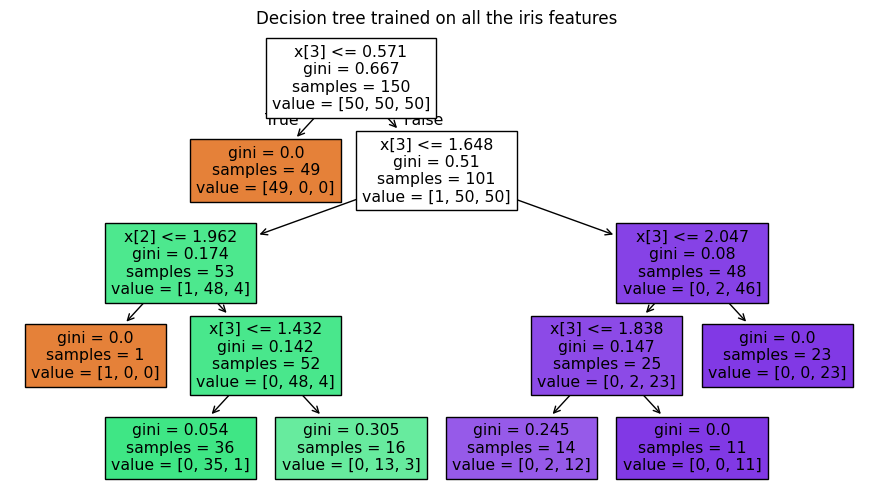

In [15]:
iris = load_iris()

X = iris.data
y = iris.target

clf = DecisionTreeClassifier(criterion="gini", splitter="random", max_depth=4, random_state=42,min_samples_split=10).fit(X, y)

plt.figure(figsize=(11, 6))
plot_tree(clf, filled=True)
plt.title("Decision tree trained on all the iris features")
plt.show()

<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  Realiza:
  <ul>
    <li> Calcula la impureza de Gini del último nivel del árbol (4 nodos) de manera manual usando la formula</li>    
  </ul>

Contesta 
<ul>
  <li> Que valor se recomienda tener en la pureza de Gini y por qué?.</li>
</ul>
</div>


In [22]:
# Calcular la impureza de Gini para los nodos del último nivel (hojas)
import numpy as np

tree = clf.tree_

# Encontrar las hojas: nodos donde children_left == -1
leaves = [node for node in range(tree.node_count) if tree.children_left[node] == -1]

print("Impureza de Gini para los 4 nodos del último nivel:")
for i, leaf in enumerate(leaves[:4]):  # Asegurarse de solo los primeros 4 si hay más
    values = tree.value[leaf][0]  # Conteos por clase
    total = np.sum(values)
    if total > 0:
        probs = values / total
        gini = 1 - np.sum(probs ** 2)
        print(f"Nodo {i+1} (ID {leaf}): Gini = {gini:.4f}, Conteos por clase: {values}")

Impureza de Gini para los 4 nodos del último nivel:
Nodo 1 (ID 1): Gini = 0.0000, Conteos por clase: [1. 0. 0.]
Nodo 2 (ID 4): Gini = 0.0000, Conteos por clase: [1. 0. 0.]
Nodo 3 (ID 6): Gini = 0.0540, Conteos por clase: [0.         0.97222222 0.02777778]
Nodo 4 (ID 7): Gini = 0.3047, Conteos por clase: [0.     0.8125 0.1875]


<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
<ul>
  <li> Que valor se recomienda tener en la pureza de Gini y por qué?.</li>
</ul>
</div>

Se recomienda tener un valor de pureza de Gini cercano a 1 (es decir, una impureza de Gini cercana a 0), porque esto indica que el nodo está compuesto principalmente por muestras de una sola clase. Esto mejora la precisión del modelo de árbol de decisión, ya que reduce la incertidumbre en las predicciones y permite clasificaciones más confiables.

El área bajo la curva (AUC-ROC) generada se utiliza ampliamente para medir el poder
discriminante del modelo, una área bajo la curva de 1 nos indicaría que nuestro modelo
clasifica correctamente todas las clases, mientras que un área de 0.5 nos indicaría que
nuestro modelo clasifica de manera aleatoria. 

Una forma de aproximar el AUC-ROC es utilizando el coeficiente de Gini.


$$AUCROC = \frac{1}{2}(G+1) $$

donde:

$G$: coeficiente de Gini.

<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  Responde
  <ul>
    <li> En que contexto se utiliza esta aproximación y por qué es utilizada?</li>
  </ul>
</div>


Esta aproximación se utiliza en el contexto de la evaluación del poder discriminante de modelos de clasificación binaria, como en el scoring crediticio o en machine learning para medir qué tan bien un modelo separa las clases positivas y negativas. Se utiliza porque el AUC-ROC es una métrica estándar para esto, pero el coeficiente de Gini (derivado de la curva de Lorenz) proporciona una medida relacionada y más interpretable en términos de desigualdad, permitiendo una aproximación rápida sin necesidad de calcular la curva ROC completa.

<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  Responde
  <ul>
    <li> Escribe en que consiste la estrategia de champion–challenger. </li>
  </ul>
</div>

La estrategia de champion-challenger consiste en comparar el rendimiento de un modelo "campeón" (el actualmente en producción) con uno o más modelos "retadores" (nuevos candidatos). Se evalúan métricas como precisión, AUC o ganancias en un conjunto de datos de validación o en producción controlada. Si un retador supera consistentemente al campeón, se reemplaza al campeón con el retador, asegurando una mejora continua del modelo sin interrupciones abruptas en el sistema.

#### Perdida esperada

 Para fines de cálculo de las reservas para riesgos crediticios se determina multiplicando la
Probabilidad de Incumplimiento (PI) por la Severidad de la Pérdida (SP) y la Exposición al Incumplimiento (EI).

$$PE = PI \times SP \times EI$$

 
  - PI dice qué tan probable es que no pague.
  - SP dice cuánto se pierde si no paga considerando recuperaciones y garantias.
  - EI dice cuánto dinero estaba en riesgo.


| Crédito | Probabilidad de Incumplimiento (PI) | Severidad de la Pérdida (SP) | Exposición al Incumplimiento (EI) | Pérdida Esperada (PE) |
|--------|------------------------------------|-------------------------------|-----------------------------------|-----------------------|
| A      | 100%                               | 40%                           | $1,000,000                        | $400,000                |
| B      | 50%                               | 50%                           | $800,000                          | $200,000               |
| C      | 8.0%                               | 60%                           | $500,000                          | $24,000               |
| D      | 12.0%                              | 45%                           | $300,000                          | $16,200               |
| E      | 20.0%                              | 70%                           | $200,000                          | $28,000               |


In [16]:
0.6 * 500000 * 0.08

24000.0

#### Pérdida No Esperada

La Pérdida No Esperada (PNE) o también llamada VaR de crédito se refiere a las pérdidas que se podrían
registrar en condiciones poco comunes. Una de las formas en que se puede calcular es tomando un percentil de
las pérdidas estimadas del portafolio.


In [17]:
creditos = pd.read_csv('Cred_PE.csv')
creditos

,Credito,PI,SP,EI
0,CRED_0001,0.0999,0.3111,1464022
1,CRED_0002,0.2382,0.5251,3851250
2,CRED_0003,0.1857,0.7238,1002246
3,CRED_0004,0.1537,0.6393,69675
4,CRED_0005,0.0474,0.6839,123997
...,...,...,...,...
995,CRED_0996,0.0320,0.5942,197745
996,CRED_0997,0.2302,0.7740,3842824
997,CRED_0998,0.0428,0.2414,1780992
998,CRED_0999,0.2381,0.2342,187686


In [18]:
creditos["PE"] = creditos["PI"] * creditos["SP"] * creditos["EI"]
creditos

,Credito,PI,SP,EI,PE
0,CRED_0001,0.0999,0.3111,1464022,45500.178696
1,CRED_0002,0.2382,0.5251,3851250,481709.805525
2,CRED_0003,0.1857,0.7238,1002246,134711.544096
3,CRED_0004,0.1537,0.6393,69675,6846.294067
4,CRED_0005,0.0474,0.6839,123997,4019.593389
...,...,...,...,...,...
995,CRED_0996,0.0320,0.5942,197745,3760.002528
996,CRED_0997,0.2302,0.7740,3842824,684694.397635
997,CRED_0998,0.0428,0.2414,1780992,18401.066865
998,CRED_0999,0.2381,0.2342,187686,10465.938172


In [19]:
# Vector de pérdidas
losses = creditos["PE"]

# Expected Loss (media) y un umbral para Capital (percentil alto)
EL = losses.mean()
q = 0.995                      # puedes usar 0.995 o 0.999 según tu caso
VaR = np.percentile(losses, q*100)  # percentil q de la distribución
UL = VaR - EL                 # Unexpected Loss como exceso sobre EL

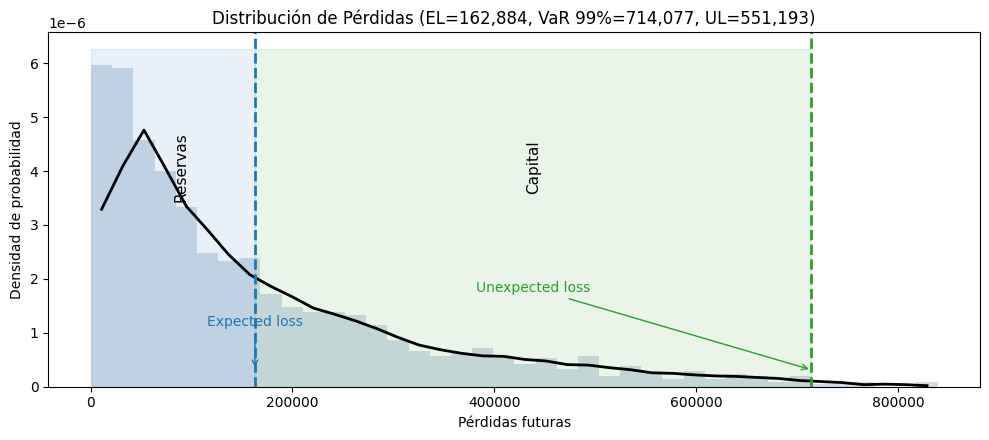

In [20]:
# Histograma + densidad (KDE aproximada con hist)
fig, ax = plt.subplots(figsize=(10, 4.5))

# Histograma en densidad
n, bins, patches = ax.hist(losses, bins=40, density=True, alpha=0.25, color="#4C78A8", edgecolor="none")

# Línea suave aproximada (usando el centro de bins y un suavizado simple)
centers = 0.5*(bins[1:] + bins[:-1])

# Suavizado (moving average) para simular curva tipo densidad
window = 5
kernel = np.ones(window)/window
smooth = np.convolve(n, kernel, mode="same")
ax.plot(centers, smooth, color="black", linewidth=2)

# Líneas verticales (EL y VaR)
ax.axvline(EL, color="#1F77B4", linestyle="--", linewidth=2)
ax.axvline(VaR, color="#2CA02C", linestyle="--", linewidth=2)

# 5) Sombreado: Reservas (0 a EL) y Capital (EL a VaR)
ymax = ax.get_ylim()[1]
ax.fill_betweenx([0, ymax], 0, EL, color="#1F77B4", alpha=0.10)
ax.fill_betweenx([0, ymax], EL, VaR, color="#2CA02C", alpha=0.10)

# 6) Etiquetas como la imagen
ax.set_ylabel("Densidad de probabilidad")
ax.set_xlabel("Pérdidas futuras")
ax.text(EL*0.55, ymax*0.65, "Reservas", rotation=90, va="center", ha="center", fontsize=11)
ax.text((EL+VaR)/2, ymax*0.65, "Capital", rotation=90, va="center", ha="center", fontsize=11)

# Anotaciones
ax.annotate("Expected loss",
            xy=(EL, ymax*0.05), xytext=(EL, ymax*0.18),
            arrowprops=dict(arrowstyle="->", color="#1F77B4"),
            ha="center", color="#1F77B4")

ax.annotate("Unexpected loss",
            xy=(VaR, ymax*0.05), xytext=((EL+VaR)/2, ymax*0.28),
            arrowprops=dict(arrowstyle="->", color="#2CA02C"),
            ha="center", color="#2CA02C")

ax.set_title(f"Distribución de Pérdidas (EL={EL:,.0f}, VaR {int(q*100)}%={VaR:,.0f}, UL={UL:,.0f})")
plt.tight_layout()
plt.show()

<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  Responde
  <ul>
    <li> ¿Por qué no basta con conocer solo la PI para medir el riesgo?</li>
  </ul>
</div>


- No basta con conocer solo la PI porque el riesgo crediticio también depende de la severidad de la pérdida (SP) y la exposición al incumplimiento (EI). La PI indica la probabilidad de que ocurra un incumplimiento, pero no cuánto se pierde si sucede, lo que requiere considerar SP y EI para una medida completa del riesgo.

<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  Responde
  <ul>
    <li> ¿Qué representa cada punto de la distribución?</li>
  </ul>
</div>

- Cada punto de la distribución representa un escenario de pérdida posible del portafolio, calculado como PE = PI × SP × EI para cada crédito, mostrando la variabilidad de las pérdidas esperadas.

<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  Responde
  <ul>
    <li> ¿Por qué la distribución es asimétrica y con cola derecha? </li>
  </ul>
</div>

- La distribución es asimétrica con cola derecha porque las pérdidas están acotadas inferiormente en cero (no hay pérdidas negativas), pero pueden ser altas cuando créditos con grandes exposiciones incurren en incumplimientos con alta severidad, creando una cola larga hacia la derecha.

<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  Responde
  <ul>
      <li> ¿Qué representa el área a la derecha del VaR? </li>
  </ul>
</div>

- El área a la derecha del VaR representa el riesgo de cola, es decir, la probabilidad de que las pérdidas excedan el valor en riesgo (VaR), correspondiente a eventos extremos más allá del nivel de confianza establecido (por ejemplo, el 0.5% restante en un VaR 99.5%).

<div style="background-color: rgba(255, 255, 0, 0.1); padding: 10px; border: 1px solid gold;">
  Realiza nuevamente el ejercicio haciendo la simulación de 1000 créditos.
  <ul>
    <li> Simula la probabilidad incumplimiento (PI) usando variables Bernoulli. </li>
    <li> Simula la exposición al incumplimiento (EI) usando variables lognormal. </li>
    <li> Simula la severidad de la perdida (SP) usando variables betas (distribución beta). </li>
    <li> Obtén pérdida esperada y perdida no esperada (VaR 95% confianza) </li>
    <li> Grafica el histograma de pérdidas. </li>
    <li> Marca la perdida esperada y no esperada. </li>
    <li> Sombrea la Reserva y Capital </li>
  </ul>
</div>


Pérdida Esperada (EL): 2,885
VaR 95%: 0
Pérdida No Esperada (UL): -2,885


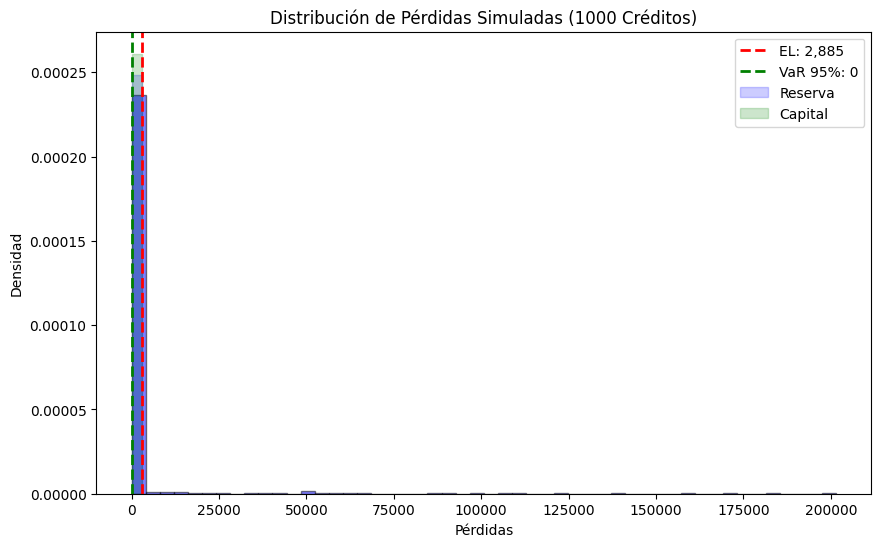

In [ ]:
from scipy.stats import beta

# Parámetros para la simulación
n_creditos = 1000
p_default = 0.05 

# Parámetros para EI (lognormal): mu y sigma en escala log
mu_ei = 12  # Media log ≈ 12.5, exp(12.5) ≈ 270,000
sigma_ei = 1

# Parámetros para SP (beta): a y b
a_sp = 2
b_sp = 5

# Simulación
np.random.seed(42)  # Para reproducibilidad

# Simular PI (indicador de default) usando Bernoulli
I = np.random.binomial(1, p_default, n_creditos)  # I ~ Bernoulli(p_default)

# Simular EI usando lognormal
EI = np.random.lognormal(mu_ei, sigma_ei, n_creditos)

# Simular SP usando beta
SP = np.random.beta(a_sp, b_sp, n_creditos)

# Calcular pérdidas: PE = I * SP * EI
losses = I * SP * EI

# Pérdida Esperada (EL)
EL = np.mean(losses)

# VaR 95% (percentil 95)
VaR_95 = np.percentile(losses, 95)

# Pérdida No Esperada (UL)
UL = VaR_95 - EL

print(f"Pérdida Esperada (EL): {EL:,.0f}")
print(f"VaR 95%: {VaR_95:,.0f}")
print(f"Pérdida No Esperada (UL): {UL:,.0f}")

# Graficar histograma
fig, ax = plt.subplots(figsize=(10, 6))

# Histograma
ax.hist(losses, bins=50, density=True, alpha=0.5, color='blue', edgecolor='black')

# Líneas verticales para EL y VaR
ax.axvline(EL, color='red', linestyle='--', linewidth=2, label=f'EL: {EL:,.0f}')
ax.axvline(VaR_95, color='green', linestyle='--', linewidth=2, label=f'VaR 95%: {VaR_95:,.0f}')

# Sombrear Reserva (0 a EL)
ax.fill_betweenx([0, ax.get_ylim()[1]], 0, EL, color='blue', alpha=0.2, label='Reserva')

# Sombrear Capital (EL a VaR)
ax.fill_betweenx([0, ax.get_ylim()[1]], EL, VaR_95, color='green', alpha=0.2, label='Capital')

# Etiquetas y título
ax.set_xlabel('Pérdidas')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de Pérdidas Simuladas (1000 Créditos)')
ax.legend()

plt.show()